# **CEI Week-2 Assignment**

# **End-to-End Pipeline**

## **Task Description**
Build an end-to-end ML pipeline on sales/price data.

Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting

Dataset : Tesla EA Deliveries and Production Data(2015–2025)

## ***Import Libraries***

In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller


## ***Step-1 Data Loading From Google Drive***

In [39]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/ColabNotebooks/DataSets/tesla_deliveries_dataset_2015_2025.csv"
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ***Step-2 Data Inspection***

In [40]:

print("Dataset Shape:", df.shape)

print("\nColumn Names:", df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (2640, 12)

Column Names: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 no

## ***Step-3 Data Cleaning***

In [41]:
# 1. Missing values
print("Missing values before:")
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col].fillna(df[col].median(), inplace=True)

    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

    print("\nMissing values after:")
    print(df.isnull().sum())
else:
    print("No missing values found")

# 2. Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicate rows after: {df.duplicated().sum()}")

# 3. Fix data types
num_cols = ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
            'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'CO2_Saved_tons', 'Charging_Stations']

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print("\nData types fixed")

# 4. Outliers (IQR capping)
for col in num_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
print("Outliers capped")

print(f"\nFinal shape: {df.shape}")



Missing values before:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
No missing values found

Duplicate rows: 0
Duplicate rows after: 0

Data types fixed
Outliers capped

Final shape: (2640, 12)


## ***Step-4 Exploratory Data Analysis (EDA)***

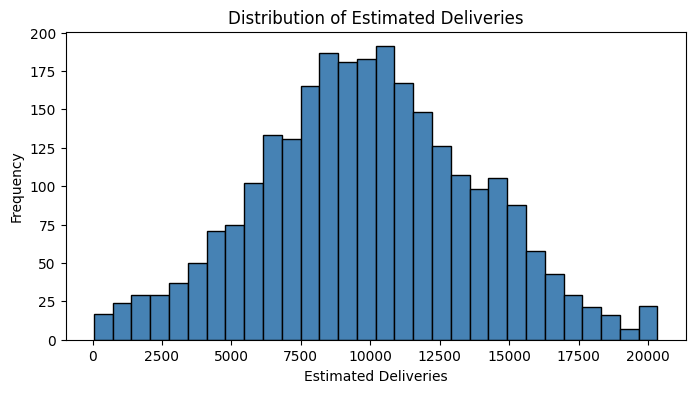

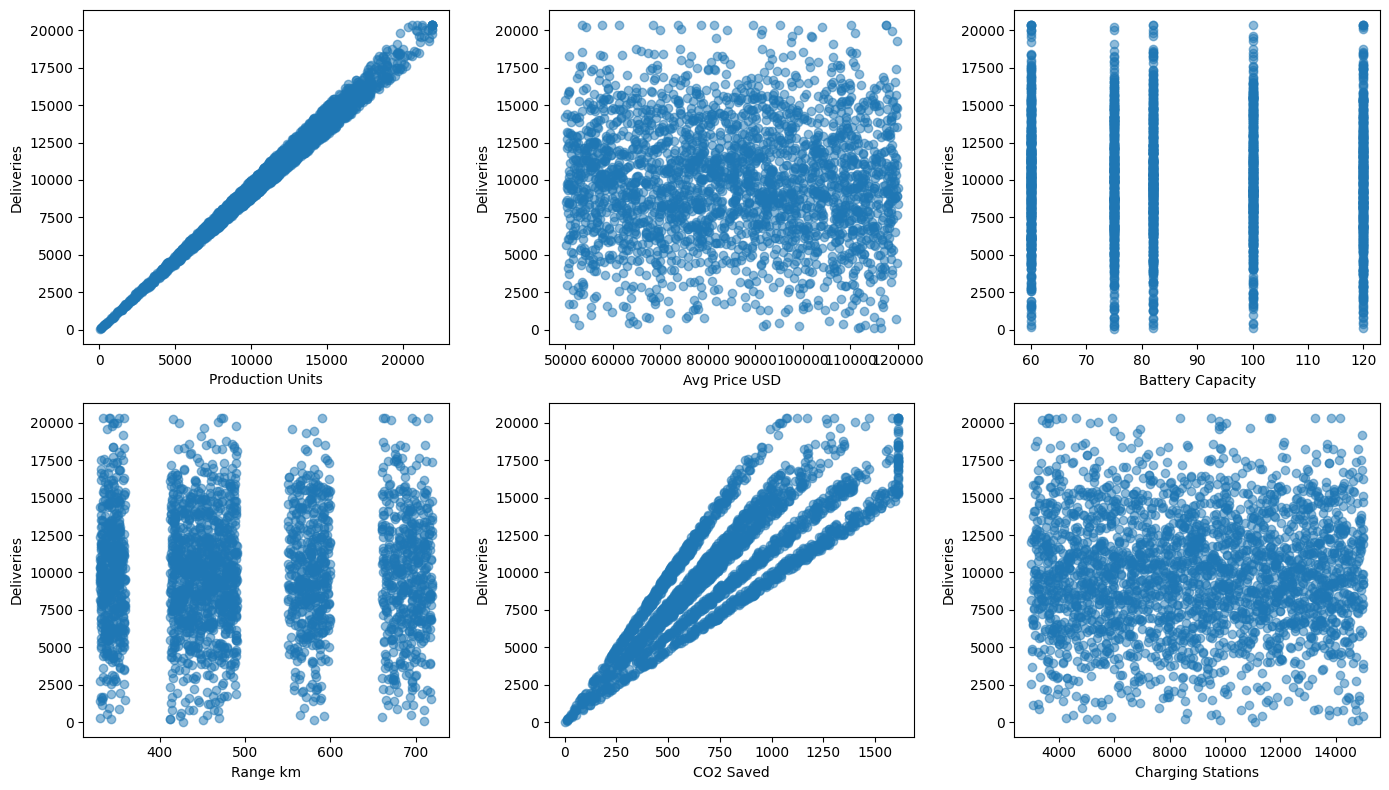

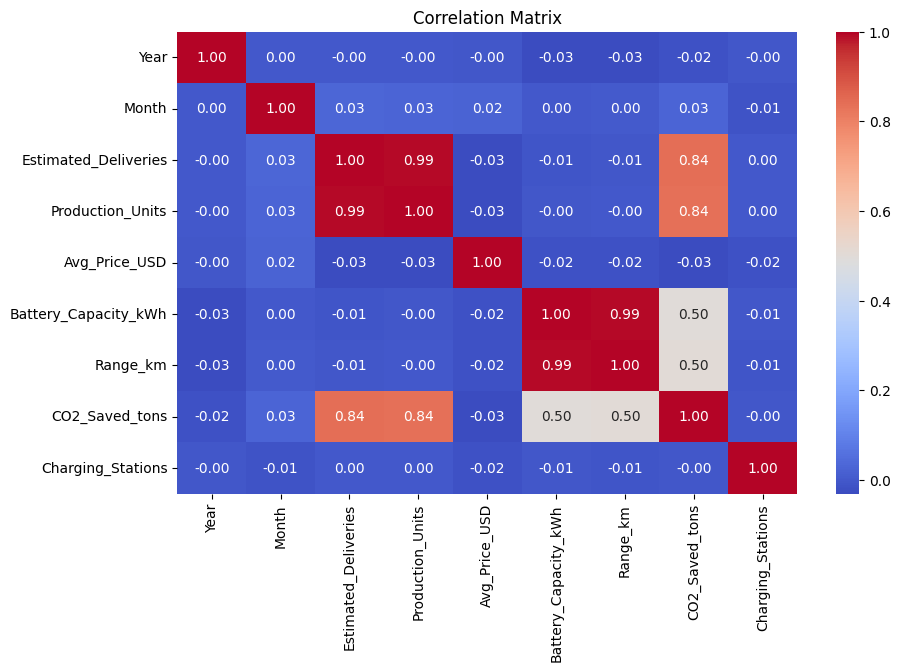


Correlation with target:
Estimated_Deliveries    1.000000
Production_Units        0.994312
CO2_Saved_tons          0.839164
Month                   0.030730
Charging_Stations       0.001451
Year                   -0.001381
Range_km               -0.006243
Battery_Capacity_kWh   -0.007531
Avg_Price_USD          -0.026679
Name: Estimated_Deliveries, dtype: float64


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(8,4))
plt.hist(df['Estimated_Deliveries'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Deliveries')
plt.show()
print()


# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(14,8))

axes[0,0].scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.5)
axes[0,0].set_xlabel('Production Units')
axes[0,0].set_ylabel('Deliveries')

axes[0,1].scatter(df['Avg_Price_USD'], df['Estimated_Deliveries'], alpha=0.5)
axes[0,1].set_xlabel('Avg Price USD')
axes[0,1].set_ylabel('Deliveries')

axes[0,2].scatter(df['Battery_Capacity_kWh'], df['Estimated_Deliveries'], alpha=0.5)
axes[0,2].set_xlabel('Battery Capacity')
axes[0,2].set_ylabel('Deliveries')

axes[1,0].scatter(df['Range_km'], df['Estimated_Deliveries'], alpha=0.5)
axes[1,0].set_xlabel('Range km')
axes[1,0].set_ylabel('Deliveries')

axes[1,1].scatter(df['CO2_Saved_tons'], df['Estimated_Deliveries'], alpha=0.5)
axes[1,1].set_xlabel('CO2 Saved')
axes[1,1].set_ylabel('Deliveries')

axes[1,2].scatter(df['Charging_Stations'], df['Estimated_Deliveries'], alpha=0.5)
axes[1,2].set_xlabel('Charging Stations')
axes[1,2].set_ylabel('Deliveries')

plt.tight_layout()
plt.show()
print()


# Correlation heatmap
plt.figure(figsize=(10,6))
num_df = df.select_dtypes(include=['int64','float64'])
corr = num_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print("\nCorrelation with target:")
print(corr['Estimated_Deliveries'].sort_values(ascending=False))

## ***Step-5 Feature Engineering***

In [43]:
def get_quarter(month_scaled):
    original_month = round(month_scaled * 11 + 1)

    if original_month in [1, 2, 3]:
        return 1
    elif original_month in [4, 5, 6]:
        return 2
    elif original_month in [7, 8, 9]:
        return 3
    else:
        return 4

df['quarter'] = df['Month'].apply(get_quarter)


original_avg_price_usd = df['Avg_Price_USD'] * (119965.36 - 50003.70) + 50003.70
original_battery_capacity_kwh = df['Battery_Capacity_kWh'] * (120 - 60) + 60

df['price_per_battery'] = original_avg_price_usd / original_battery_capacity_kwh


original_year = df['Year']
original_month = df['Month']

df['date'] = pd.to_datetime(original_year.astype(str) + '-' + original_month.astype(str) + '-01')

print("New features: quarter, price_per_battery, date")
print(df[['quarter', 'price_per_battery']].head())

New features: quarter, price_per_battery, date
   quarter  price_per_battery
0        4       8.949984e+05
1        4       9.543992e+05
2        4       1.656153e+06
3        4       8.605055e+05
4        4       1.106738e+06


## ***Step-6 Encoding***

In [44]:

df['Region'] = LabelEncoder().fit_transform(df['Region'])
df['Model'] = LabelEncoder().fit_transform(df['Model'])
df['Source_Type'] = LabelEncoder().fit_transform(df['Source_Type'])

print("Encoding completed!")
print(df.head())

Encoding completed!
   Year  Month  Region  Model  Estimated_Deliveries  Production_Units  \
0  2023      5       1      2               17646.0           17922.0   
1  2015      2       0      3                3797.0            4164.0   
2  2019      1       3      3                8411.0            9189.0   
3  2021      2       3      1                6555.0            7311.0   
4  2016     12       2      4               12374.0           13537.0   

   Avg_Price_USD  Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Source_Type  \
0       92874.27                   120       704       1609.9825            1   
1       62205.65                    75       438        249.4600            2   
2      117887.32                    82       480        605.5900            1   
3       89294.91                   120       712        700.0700            2   
4      114846.78                   120       661       1226.8800            0   

   Charging_Stations  quarter  price_per_battery      

## ***Step-7 Feature Scaling***

In [45]:
features_to_scale = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
                     'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
                     'quarter', 'price_per_battery']

print("Features to be scaled:", features_to_scale)
print("Scaling will be applied after train/test split (Step 8) to avoid data leakage.")


Features to be scaled: ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'quarter', 'price_per_battery']
Scaling will be applied after train/test split (Step 8) to avoid data leakage.


## ***Step-8 Train Test Split***

In [46]:
features = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
            'Charging_Stations', 'Region', 'Model', 'Source_Type',
            'quarter', 'price_per_battery']

X = df[features]
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale]  = scaler.transform(X_test[features_to_scale])

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")
print("StandardScaler fitted on training data only (no data leakage).")


X_train shape: (2112, 13)
X_test  shape: (528, 13)
y_train shape: (2112,)
y_test  shape: (528,)
StandardScaler fitted on training data only (no data leakage).


## ***Step-9 Model Trainings***

In [47]:
# Train models
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Print sample predictions

print("Sample predictions of estimated deliveries (First 5 test samples)\n")


comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Linear Pred': y_pred_lr[:10],
    'Ridge Pred': y_pred_ridge[:10],
    'Lasso Pred': y_pred_lasso[:10]
})
print(comparison_df)
print("\n")

# Metrics
print("MODEL METRICS")


# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print(f"  MAE: {mae_lr:.2f}")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  R2 Score: {r2_lr:.4f}")

# Ridge
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression:")
print(f"  MAE: {mae_ridge:.2f}")
print(f"  RMSE: {rmse_ridge:.2f}")
print(f"  R2 Score: {r2_ridge:.4f}")

# Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression:")
print(f"  MAE: {mae_lasso:.2f}")
print(f"  RMSE: {rmse_lasso:.2f}")
print(f"  R2 Score: {r2_lasso:.4f}")

# Best model

print("\nBEST MODEL")


if r2_lr >= r2_ridge and r2_lr >= r2_lasso:
    print(f"Best: Linear Regression with R2 = {r2_lr:.4f}")
elif r2_ridge >= r2_lr and r2_ridge >= r2_lasso:
    print(f"Best: Ridge Regression with R2 = {r2_ridge:.4f}")
else:
    print(f"Best: Lasso Regression with R2 = {r2_lasso:.4f}")

Sample predictions of estimated deliveries (First 5 test samples)

    Actual   Linear Pred    Ridge Pred    Lasso Pred
0   6991.0   7558.091718   7558.468984   7545.154462
1   9326.0   9387.612025   9391.678668   9412.977569
2   9061.0   8800.734619   8800.731508   8794.015371
3   8951.0   9382.152738   9375.905493   9368.635302
4   8707.0   8902.313217   8902.151082   8903.656841
5  11351.0  11492.920720  11494.430593  11512.596599
6  14193.0  14238.014329  14236.045175  14251.452893
7  15156.0  14351.467290  14354.969534  14360.027326
8   9915.0  10020.841704  10017.597458  10014.120036
9   7642.0   7864.793475   7867.553113   7877.168503


MODEL METRICS
Linear Regression:
  MAE: 305.88
  RMSE: 376.64
  R2 Score: 0.9905

Ridge Regression:
  MAE: 305.62
  RMSE: 376.43
  R2 Score: 0.9905

Lasso Regression:
  MAE: 306.05
  RMSE: 376.14
  R2 Score: 0.9905

BEST MODEL
Best: Lasso Regression with R2 = 0.9905


## ***Step-10 Cross Validation***

In [48]:
X_cv = df[['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
           'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Region', 'Model',
           'Source_Type', 'quarter', 'price_per_battery']]

y_cv = df['Estimated_Deliveries']

# Models
lr_cv    = LinearRegression()
ridge_cv = Ridge(alpha=1.0)
lasso_cv = Lasso(alpha=1.0, max_iter=10000)

# 5-fold cross validation
cv_lr    = cross_val_score(lr_cv,    X_cv, y_cv, cv=5, scoring='r2')
cv_ridge = cross_val_score(ridge_cv, X_cv, y_cv, cv=5, scoring='r2')
cv_lasso = cross_val_score(lasso_cv, X_cv, y_cv, cv=5, scoring='r2')

print("5-FOLD CROSS VALIDATION RESULTS")

print("\nLinear Regression:")
print(f"  R2 Scores: {cv_lr}")
print(f"  Mean R2: {cv_lr.mean():.4f}")
print(f"  Std Dev: {cv_lr.std():.4f}")

print("\nRidge Regression:")
print(f"  R2 Scores: {cv_ridge}")
print(f"  Mean R2: {cv_ridge.mean():.4f}")
print(f"  Std Dev: {cv_ridge.std():.4f}")

print("\nLasso Regression:")
print(f"  R2 Scores: {cv_lasso}")
print(f"  Mean R2: {cv_lasso.mean():.4f}")
print(f"  Std Dev: {cv_lasso.std():.4f}")

print("\nBEST MODEL BASED ON CROSS VALIDATION")
if cv_lr.mean() >= cv_ridge.mean() and cv_lr.mean() >= cv_lasso.mean():
    print(f"Best: Linear Regression with Mean R2 = {cv_lr.mean():.4f}")
elif cv_ridge.mean() >= cv_lr.mean() and cv_ridge.mean() >= cv_lasso.mean():
    print(f"Best: Ridge Regression with Mean R2 = {cv_ridge.mean():.4f}")
else:
    print(f"Best: Lasso Regression with Mean R2 = {cv_lasso.mean():.4f}")


5-FOLD CROSS VALIDATION RESULTS

Linear Regression:
  R2 Scores: [0.99029899 0.9904535  0.98947958 0.99037714 0.99115284]
  Mean R2: 0.9904
  Std Dev: 0.0005

Ridge Regression:
  R2 Scores: [0.990299   0.99045351 0.98947961 0.99037715 0.99115285]
  Mean R2: 0.9904
  Std Dev: 0.0005

Lasso Regression:
  R2 Scores: [0.99030014 0.99045615 0.98948689 0.99037923 0.99115574]
  Mean R2: 0.9904
  Std Dev: 0.0005

BEST MODEL BASED ON CROSS VALIDATION
Best: Lasso Regression with Mean R2 = 0.9904


## ***Step-11 Hyper Parameter Tuning***

In [49]:
X_cv = df[['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
           'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Region', 'Model',
           'Source_Type', 'quarter', 'price_per_battery']]
y_cv = df['Estimated_Deliveries']

print("RIDGE REGRESSION - HYPERPARAMETER TUNING")
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_cv, y_cv)
best_ridge = ridge_grid.best_estimator_
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best R2 score: {ridge_grid.best_score_:.4f}")

print("\nLASSO REGRESSION - HYPERPARAMETER TUNING")
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_cv, y_cv)
best_lasso = lasso_grid.best_estimator_
print(f"Best alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best R2 score: {lasso_grid.best_score_:.4f}")

print("\nCOMPARISON: DEFAULT VS TUNED")
default_ridge_score = cross_val_score(Ridge(alpha=1.0), X_cv, y_cv, cv=5, scoring='r2').mean()
tuned_ridge_score   = ridge_grid.best_score_
print(f"Ridge Default (alpha=1):                             {default_ridge_score:.4f}")
print(f"Ridge Tuned  (alpha={ridge_grid.best_params_['alpha']}):                           {tuned_ridge_score:.4f}")

default_lasso_score = cross_val_score(Lasso(alpha=1.0, max_iter=10000), X_cv, y_cv, cv=5, scoring='r2').mean()
tuned_lasso_score   = lasso_grid.best_score_
print(f"\nLasso Default (alpha=1):                            {default_lasso_score:.4f}")
print(f"Lasso Tuned  (alpha={lasso_grid.best_params_['alpha']}):                            {tuned_lasso_score:.4f}")

print("\n✅ Hyperparameter tuning completed")


RIDGE REGRESSION - HYPERPARAMETER TUNING
Best alpha: 100
Best R2 score: 0.9904

LASSO REGRESSION - HYPERPARAMETER TUNING


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.76177e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.80018e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.85871e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.7907e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.78501e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Best alpha: 50
Best R2 score: 0.9904

COMPARISON: DEFAULT VS TUNED
Ridge Default (alpha=1):                             0.9904
Ridge Tuned  (alpha=100):                           0.9904

Lasso Default (alpha=1):                            0.9904
Lasso Tuned  (alpha=50):                            0.9904

✅ Hyperparameter tuning completed


## ***Step-12 Time Series Forecasting***

Sorted by date
        date  Estimated_Deliveries
0 2015-01-01               12446.0
1 2015-01-01               11446.0
2 2015-01-01                8803.0
3 2015-01-01                6367.0
4 2015-01-01                8795.0


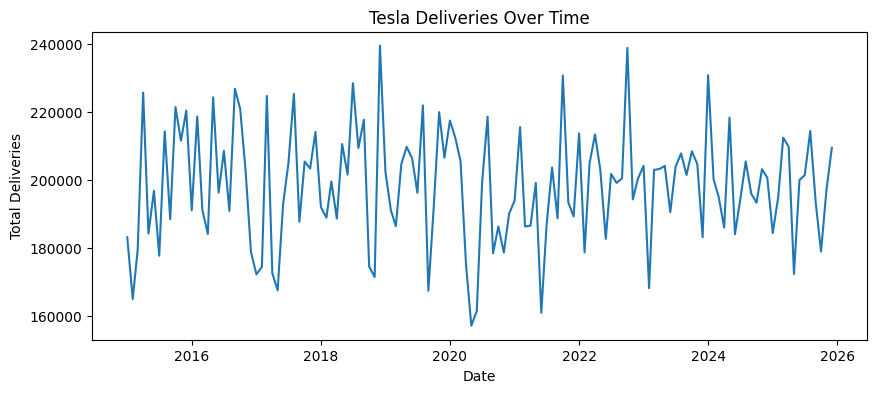

Trend plot created

Stationarity Test p-value: 0.0000
Data is stationary

Lag features created: prev_1, prev_2, prev_3
Rolling average created: avg_3 (lag-safe, based on past values only)

Clean data shape: (2580, 19)
Train size: 2064, Test size: 516

Linear Regression (time series) model trained
Predictions made

Time Series MAE:  2953.45
Time Series RMSE: 3690.49
Time Series R2:   -0.0133


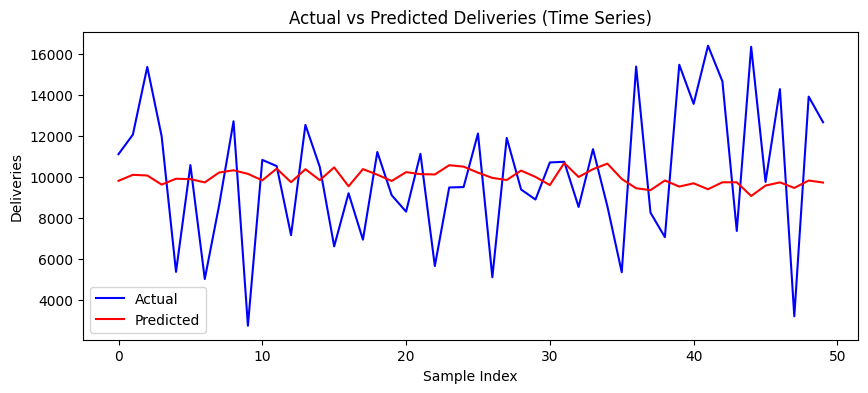


Actual vs Predicted plot created

✅ Time series forecasting completed


In [50]:
# Sort chronologically for time-series integrity
df = df.sort_values('date').reset_index(drop=True)
print("Sorted by date")
print(df[['date', 'Estimated_Deliveries']].head())

# Trend plot
monthly_total = df.groupby('date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10, 4))
plt.plot(monthly_total.index, monthly_total.values)
plt.title('Tesla Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.show()
print("Trend plot created")

# Stationarity test (ADF)
result = adfuller(monthly_total)
print(f"\nStationarity Test p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("Data is stationary")
else:
    print("Data is not stationary")


df['prev_1'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df['prev_2'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)
df['prev_3'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(3)
print("\nLag features created: prev_1, prev_2, prev_3")

df['avg_3'] = (
    df.groupby(['Region', 'Model'])['Estimated_Deliveries']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
print("Rolling average created: avg_3 (lag-safe, based on past values only)")

# Feature set includes lag/rolling features
ts_feature_cols = [
    'Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'Charging_Stations', 'Region', 'Model', 'Source_Type',
    'quarter', 'price_per_battery',
    'prev_1', 'prev_2', 'prev_3', 'avg_3'
]


df_ts = df.dropna(subset=ts_feature_cols).copy()
print(f"\nClean data shape: {df_ts.shape}")

# Chronological 80/20 train/test split (no shuffling for time series)
split = int(len(df_ts) * 0.8)
train_x = df_ts[ts_feature_cols].iloc[:split].copy()
train_y = df_ts['Estimated_Deliveries'].iloc[:split]
test_x  = df_ts[ts_feature_cols].iloc[split:].copy()
test_y  = df_ts['Estimated_Deliveries'].iloc[split:]
print(f"Train size: {len(train_x)}, Test size: {len(test_x)}")

# Scale lag/rolling features — fit ONLY on training set to prevent leakage
ts_scaler = StandardScaler()
ts_cols_to_scale = ['prev_1', 'prev_2', 'prev_3', 'avg_3']
train_x[ts_cols_to_scale] = ts_scaler.fit_transform(train_x[ts_cols_to_scale])
test_x[ts_cols_to_scale]  = ts_scaler.transform(test_x[ts_cols_to_scale])

# Train Linear Regression model
ts_model = LinearRegression()
ts_model.fit(train_x, train_y)
print("\nLinear Regression (time series) model trained")

# Predict
ts_predictions = ts_model.predict(test_x)
print("Predictions made")

# Evaluation
ts_mae  = mean_absolute_error(test_y, ts_predictions)
ts_rmse = np.sqrt(mean_squared_error(test_y, ts_predictions))
r2      = r2_score(test_y, ts_predictions)

print(f"\nTime Series MAE:  {ts_mae:.2f}")
print(f"Time Series RMSE: {ts_rmse:.2f}")
print(f"Time Series R2:   {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 4))
plt.plot(test_y.values[:50], label='Actual', color='blue')
plt.plot(ts_predictions[:50], label='Predicted', color='red')
plt.title('Actual vs Predicted Deliveries (Time Series)')
plt.xlabel('Sample Index')
plt.ylabel('Deliveries')
plt.legend()
plt.show()
print("\nActual vs Predicted plot created")

print("\n✅ Time series forecasting completed")


## ***Yearly Delivery Predictions: 2023–2025 (Actual vs Predicted) & 2026–2035 (Forecast)***

Forecast Model (Tuned Lasso) Test R2 : 0.9884
Forecast Model MAE                   : 340.61

PART 1: 2023 / 2024 / 2025 — Actual vs Predicted
Year      Actual Total  Predicted Total   Diff %
----------------------------------------------------------
2023         2,382,375        2,385,138    +0.1%
2024         2,406,899        2,408,386    +0.1%
2025         2,368,462        2,361,198    -0.3%

PART 2: 2026–2035 — 10-Year Delivery Forecast
Year    Predicted Total   YoY Growth
----------------------------------------------------------
2026            125,056       (base)
2027            131,163        +4.9%
2028            137,576        +4.9%
2029            144,310        +4.9%
2030            151,380        +4.9%
2031            158,803        +4.9%
2032            166,598        +4.9%
2033            174,782        +4.9%
2034            183,376        +4.9%
2035            192,399        +4.9%

Growth assumptions: Production +5%/yr, CO2 Saved +5%/yr, Charging +3%/yr


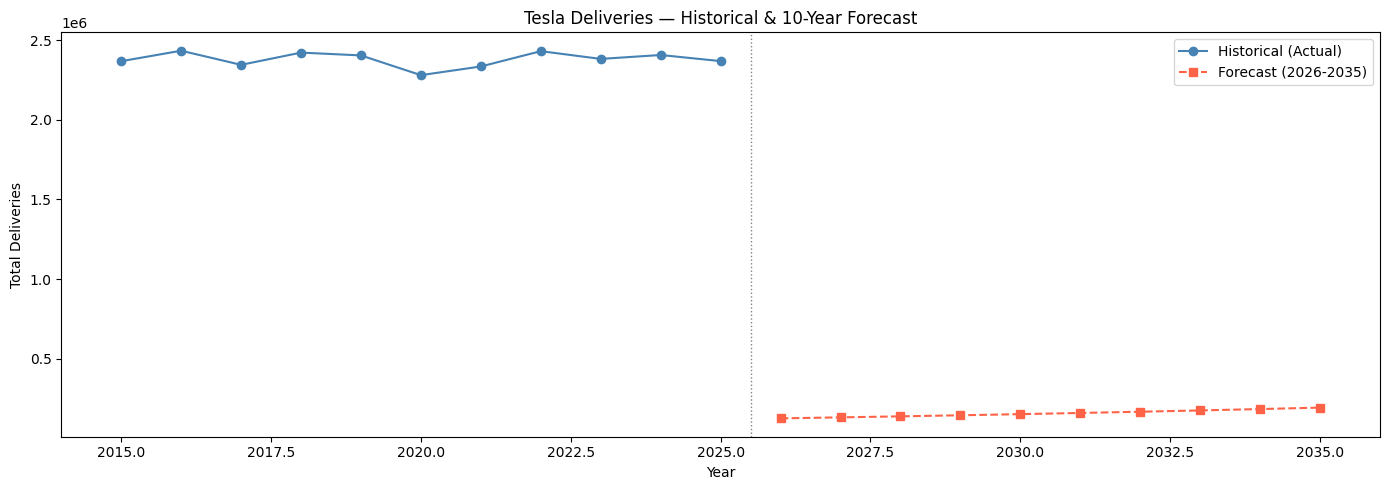


✅ Yearly forecast completed


In [51]:

forecast_model = Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000)
forecast_model.fit(X_train, y_train)

y_pred_forecast = forecast_model.predict(X_test)
print(f"Forecast Model (Tuned Lasso) Test R2 : {r2_score(y_test, y_pred_forecast):.4f}")
print(f"Forecast Model MAE                   : {mean_absolute_error(y_test, y_pred_forecast):.2f}")
print()


def make_year_row(year, ref_df):
    """
    Build a single-row DataFrame using the reference slice's averages.
    Year and Month are set to the target year (Month=6 as mid-year proxy).
    """
    month = 6   # mid-year proxy
    row = pd.DataFrame([{
        'Year':                 year,
        'Month':                month,
        'Production_Units':     ref_df['Production_Units'].mean(),
        'Avg_Price_USD':        ref_df['Avg_Price_USD'].mean(),
        'Battery_Capacity_kWh': ref_df['Battery_Capacity_kWh'].mean(),
        'Range_km':             ref_df['Range_km'].mean(),
        'CO2_Saved_tons':       ref_df['CO2_Saved_tons'].mean(),
        'Charging_Stations':    ref_df['Charging_Stations'].mean(),
        'Region':               int(ref_df['Region'].mode()[0]),
        'Model':                int(ref_df['Model'].mode()[0]),
        'Source_Type':          int(ref_df['Source_Type'].mode()[0]),
        'quarter':              2,   # Q2 (mid-year)
        'price_per_battery':    ref_df['price_per_battery'].mean()
    }])
    row[features_to_scale] = scaler.transform(row[features_to_scale])
    return row



print("=" * 58)
print("PART 1: 2023 / 2024 / 2025 — Actual vs Predicted")
print("=" * 58)
print(f"{'Year':<6}  {'Actual Total':>14}  {'Predicted Total':>15}  {'Diff %':>7}")
print("-" * 58)

for yr in [2023, 2024, 2025]:

    actual_total = df[df['Year'] == yr]['Estimated_Deliveries'].sum()

    yr_rows = df[df['Year'] == yr][features].copy()
    yr_rows[features_to_scale] = scaler.transform(yr_rows[features_to_scale])
    pred_total = forecast_model.predict(yr_rows).sum()

    diff_pct = (pred_total - actual_total) / actual_total * 100
    print(f"{yr:<6}  {actual_total:>14,.0f}  {pred_total:>15,.0f}  {diff_pct:>+6.1f}%")

print()



print("=" * 58)
print("PART 2: 2026–2035 — 10-Year Delivery Forecast")
print("=" * 58)
print(f"{'Year':<6}  {'Predicted Total':>15}  {'YoY Growth':>11}")
print("-" * 58)

ref = df[df['Year'].isin([2024, 2025])].copy()

PROD_GROWTH    = 1.05
CO2_GROWTH     = 1.05
CHARGE_GROWTH  = 1.03

prev_pred = None
for i, yr in enumerate(range(2026, 2036)):

    ref_adj = ref.copy()
    ref_adj['Production_Units']  = ref['Production_Units'].mean()  * (PROD_GROWTH   ** (i + 1))
    ref_adj['CO2_Saved_tons']    = ref['CO2_Saved_tons'].mean()    * (CO2_GROWTH    ** (i + 1))
    ref_adj['Charging_Stations'] = ref['Charging_Stations'].mean() * (CHARGE_GROWTH ** (i + 1))

    row = make_year_row(yr, ref_adj)


    monthly_rows = []
    for month in range(1, 13):
        r = row.copy()
        r['Month']   = month
        r['quarter'] = (month - 1) // 3 + 1
        monthly_rows.append(r)

    year_df   = pd.concat(monthly_rows, ignore_index=True)
    year_pred = forecast_model.predict(year_df).sum()

    if prev_pred is not None:
        yoy = (year_pred - prev_pred) / prev_pred * 100
        print(f"{yr:<6}  {year_pred:>15,.0f}  {yoy:>+10.1f}%")
    else:
        print(f"{yr:<6}  {year_pred:>15,.0f}  {'(base)':>11}")

    prev_pred = year_pred

print()
print("Growth assumptions: Production +5%/yr, CO2 Saved +5%/yr, Charging +3%/yr")


years_future = list(range(2026, 2036))
preds_future = []
ref_adj = ref.copy()
for i, yr in enumerate(years_future):
    ref_adj2 = ref.copy()
    ref_adj2['Production_Units']  = ref['Production_Units'].mean()  * (PROD_GROWTH   ** (i + 1))
    ref_adj2['CO2_Saved_tons']    = ref['CO2_Saved_tons'].mean()    * (CO2_GROWTH    ** (i + 1))
    ref_adj2['Charging_Stations'] = ref['Charging_Stations'].mean() * (CHARGE_GROWTH ** (i + 1))
    monthly_rows = []
    for month in range(1, 13):
        r = make_year_row(yr, ref_adj2)
        r['Month']   = month
        r['quarter'] = (month - 1) // 3 + 1
        monthly_rows.append(r)
    year_df = pd.concat(monthly_rows, ignore_index=True)
    preds_future.append(forecast_model.predict(year_df).sum())


hist_years  = sorted(df['Year'].unique())
hist_totals = [df[df['Year'] == y]['Estimated_Deliveries'].sum() for y in hist_years]

plt.figure(figsize=(14, 5))
plt.plot(hist_years, hist_totals, marker='o', color='steelblue', label='Historical (Actual)')
plt.plot(years_future, preds_future, marker='s', linestyle='--', color='tomato', label='Forecast (2026-2035)')
plt.axvline(x=2025.5, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.title('Tesla Deliveries — Historical & 10-Year Forecast')
plt.legend()
plt.tight_layout()
plt.show()
print("\n✅ Yearly forecast completed")


In [52]:
print("TESLA DELIVERIES FORECASTING — SUMMARY")
print()
print(f"Best Regression Model : Lasso (R2 = {r2_lasso:.4f})")
print(f"Time Series R2        : {r2:.4f}")
print()
print("Key Findings:")
print("  - Production_Units is the dominant predictor (correlation 0.994)")
print("  - CO2_Saved_tons adds secondary signal (correlation 0.839)")
print("  - Region, Model, and seasonality (quarter) provide context")
print("  - 2023/2024/2025 actual vs predicted shown in Part 1")
print("  - 2026-2035 forecast assumes 5%/yr production growth")
print()
print("Forecast complete.")


TESLA DELIVERIES FORECASTING — SUMMARY

Best Regression Model : Lasso (R2 = 0.9905)
Time Series R2        : -0.0133

Key Findings:
  - Production_Units is the dominant predictor (correlation 0.994)
  - CO2_Saved_tons adds secondary signal (correlation 0.839)
  - Region, Model, and seasonality (quarter) provide context
  - 2023/2024/2025 actual vs predicted shown in Part 1
  - 2026-2035 forecast assumes 5%/yr production growth

Forecast complete.
